# 📝 EDA Worksheet — Auto-MPG Dataset
**Student Name:** ___________________________  |  **Date:** _______________

Complete every `# TODO` cell. Run the cells in order.  
Answer the written questions in the Markdown cells provided.

---
**Dataset:** Auto-MPG (UCI) | 398 rows × 9 columns


## Task 1 — Import Libraries

In [1]:
# TODO: Import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
# Also set sns theme to 'whitegrid' and default figure size to (10,5)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10,5)
pd.set_option('display.max_columns', None)
print ("Libraries Loaded")


Matplotlib is building the font cache; this may take a moment.


Libraries Loaded


## Task 2 — Load & Inspect Data

In [2]:
# TODO: Load the Auto-MPG dataset from the UCI repository URL below.
# Column names: ['mpg','cylinders','displacement','horsepower','weight',
#                'acceleration','model_year','origin','car_name']
# Missing values are marked with '?'
# URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
col_names = ['mpg','cylinders','displacement','horsepower','weight',
             'acceleration','model_year','origin','car_name']

df = pd.read_csv(url, sep=r'\s+', names=col_names, na_values='?')

print("Shape:", df.shape)
df.head()


Shape: (398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [3]:
# TODO: Print df.info() to inspect dtypes and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    str    
dtypes: float64(5), int64(3), str(1)
memory usage: 28.1 KB


In [4]:
# TODO: Print df.describe() to view summary statistics
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


**Q1.** How many rows and columns does the dataset have?  
**Answer:** _There are 9 columns and 398 rows in dataset_

**Q2.** Which column contains missing values and how many?  
**Answer:** _Horsepower column has 6 missing values_


## Task 3 — Pre-Processing

In [5]:
# TODO: Check and print missing values per column
# Then drop all rows that contain NaN values (they are < 2% of data)

print("Missing values before dropping:")
print(df.isna().sum())

total_null_values = df.isna().sum().sum()
total_data_points = df.shape[0] * df.shape[1]
percentage_null = (total_null_values / total_data_points) * 100
print(f"\nPercentage of null values in the data: {percentage_null:.2f}%")

df.dropna(inplace=True)
print("\nMissing values after dropping:")
print(df.isna().sum())

Missing values before dropping:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

Percentage of null values in the data: 0.17%

Missing values after dropping:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64


In [6]:
# TODO: Check for and remove duplicate rows

print(f"Number of duplicate rows before dropping: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Number of duplicate rows after dropping: {df.duplicated().sum()}")

Number of duplicate rows before dropping: 0
Number of duplicate rows after dropping: 0


In [7]:
# TODO:
# 1. Convert 'cylinders' and 'model_year' to category dtype
# 2. Map 'origin' from {1,2,3} to {'usa','europe','japan'}
# 3. Strip & lowercase 'car_name'

# Convert to category dtype
df['cylinders'] = df['cylinders'].astype('category')
df['model_year'] = df['model_year'].astype('category')

# Map 'origin'
origin_map = {1: 'usa', 2: 'europe', 3: 'japan'}
df['origin'] = df['origin'].map(origin_map).astype('category')

# Strip & lowercase 'car_name'
df['car_name'] = df['car_name'].str.strip().str.lower()

print("Data types after conversion:")
print(df[['cylinders', 'model_year', 'origin']].dtypes)


Data types after conversion:
cylinders     category
model_year    category
origin        category
dtype: object


In [8]:
# TODO: Create two lists:
# cat_cols — categorical column names (cylinders, origin, model_year)
# num_cols — numerical column names (mpg, displacement, horsepower, weight, acceleration)

cat_cols = ['cylinders', 'origin', 'model_year']
num_cols = ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']

print(f"Categorical columns: {cat_cols}")
print(f"Numerical columns: {num_cols}")

Categorical columns: ['cylinders', 'origin', 'model_year']
Numerical columns: ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']


## Task 4 — Feature Engineering

In [9]:
# TODO: Create 'mpg_level' column using pd.cut()
# Bins: [0,17) → 'low', [17,29) → 'medium', [29, max] → 'high'

bins = [0, 17, 29, df['mpg'].max() + 1]
labels = ['low', 'medium', 'high']
df['mpg_level'] = pd.cut(df['mpg'], bins=bins, labels=labels, right=False)

print("Value counts for 'mpg_level':")
print(df['mpg_level'].value_counts())
display(df.head())

Value counts for 'mpg_level':
mpg_level
medium    197
high      103
low        92
Name: count, dtype: int64


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name,mpg_level
0,18.0,8,307.0,130.0,3504.0,12.0,70,usa,chevrolet chevelle malibu,medium
1,15.0,8,350.0,165.0,3693.0,11.5,70,usa,buick skylark 320,low
2,18.0,8,318.0,150.0,3436.0,11.0,70,usa,plymouth satellite,medium
3,16.0,8,304.0,150.0,3433.0,12.0,70,usa,amc rebel sst,low
4,17.0,8,302.0,140.0,3449.0,10.5,70,usa,ford torino,medium


In [10]:
# TODO: Create 'car_company' by extracting the first word from 'car_name'

df['car_company'] = df['car_name'].apply(lambda x: x.split(' ')[0])

print("Value counts for 'car_company':")
print(df['car_company'].value_counts().head())
display(df.head())

Value counts for 'car_company':
car_company
ford         48
chevrolet    43
plymouth     31
dodge        28
amc          27
Name: count, dtype: int64


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name,mpg_level,car_company
0,18.0,8,307.0,130.0,3504.0,12.0,70,usa,chevrolet chevelle malibu,medium,chevrolet
1,15.0,8,350.0,165.0,3693.0,11.5,70,usa,buick skylark 320,low,buick
2,18.0,8,318.0,150.0,3436.0,11.0,70,usa,plymouth satellite,medium,plymouth
3,16.0,8,304.0,150.0,3433.0,12.0,70,usa,amc rebel sst,low,amc
4,17.0,8,302.0,140.0,3449.0,10.5,70,usa,ford torino,medium,ford


## Task 5 — Categorical EDA

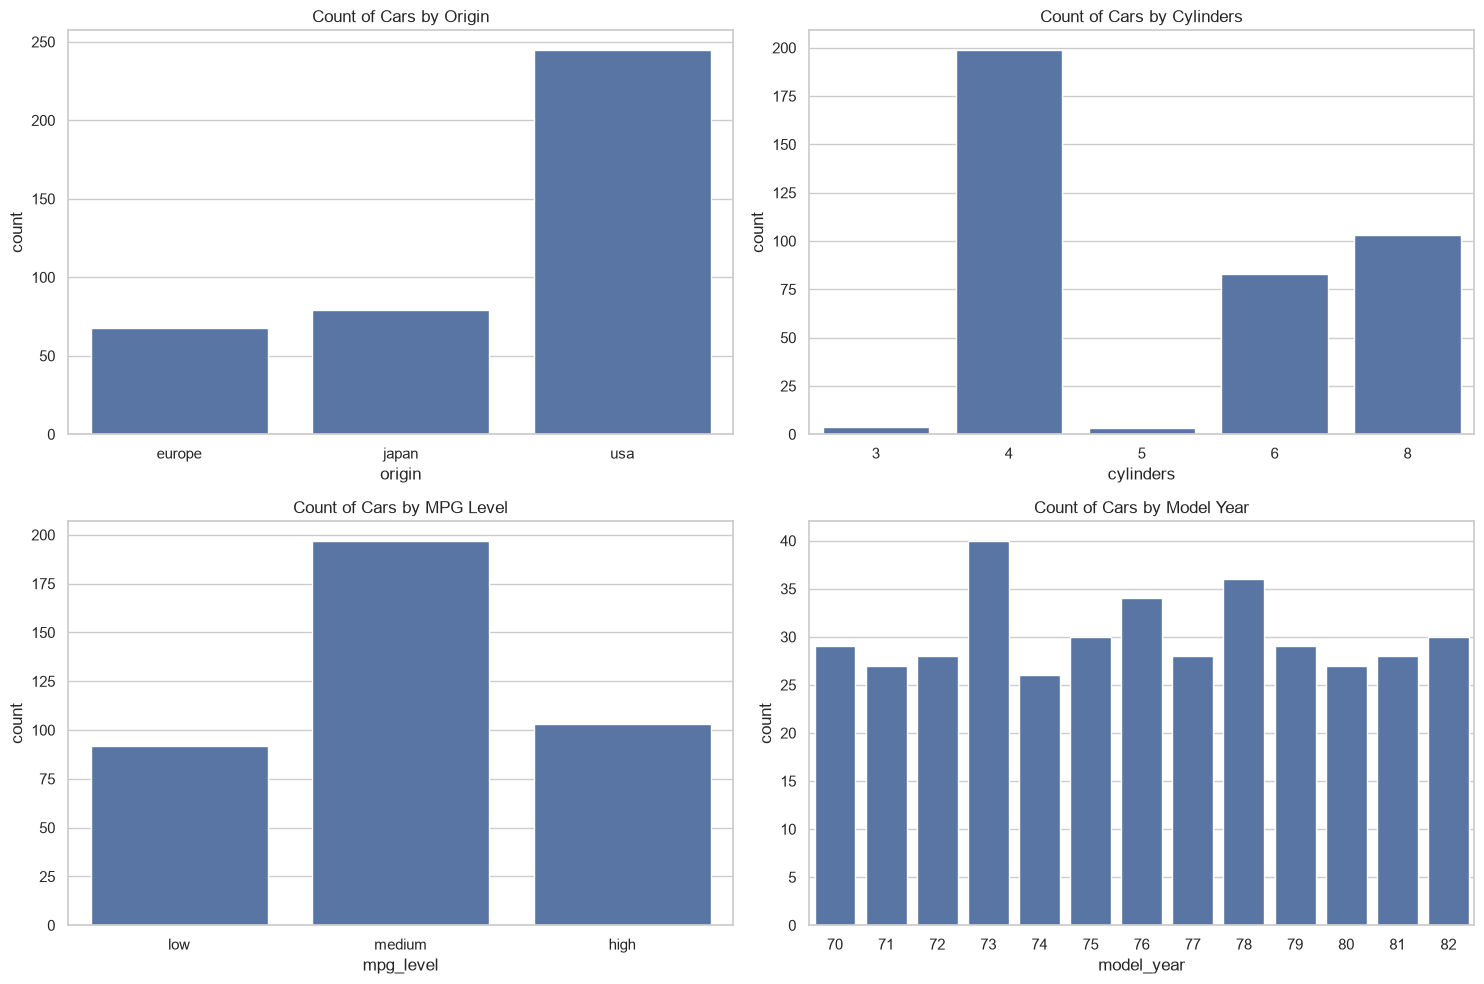

In [11]:
# TODO: Plot a countplot for each of: origin, cylinders, mpg_level, model_year
# Arrange them in a 2×2 grid of subplots

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.countplot(data=df, x='origin', ax=axes[0, 0])
axes[0, 0].set_title('Count of Cars by Origin')

sns.countplot(data=df, x='cylinders', ax=axes[0, 1])
axes[0, 1].set_title('Count of Cars by Cylinders')

sns.countplot(data=df, x='mpg_level', ax=axes[1, 0])
axes[1, 0].set_title('Count of Cars by MPG Level')

sns.countplot(data=df, x='model_year', ax=axes[1, 1])
axes[1, 1].set_title('Count of Cars by Model Year')

plt.tight_layout()
plt.show()

In [12]:
# TODO: Print the proportion (%) of the dominant class for
# origin, cylinders, and mpg_level

print("Dominant class proportions:")
for col in ['origin', 'cylinders', 'mpg_level']:
    dominant_class_count = df[col].value_counts().max()
    total_count = df[col].count()
    proportion = (dominant_class_count / total_count) * 100
    dominant_value = df[col].value_counts().idxmax()
    print(f"{col}: {dominant_value} ({proportion:.2f}%) is the dominant class")

Dominant class proportions:
origin: usa (62.50%) is the dominant class
cylinders: 4 (50.77%) is the dominant class
mpg_level: medium (50.26%) is the dominant class


Crosstab of Cylinders vs Origin:


origin,europe,japan,usa
cylinders,,,
3,0,4,0
4,61,69,69
5,3,0,0
6,4,6,73
8,0,0,103


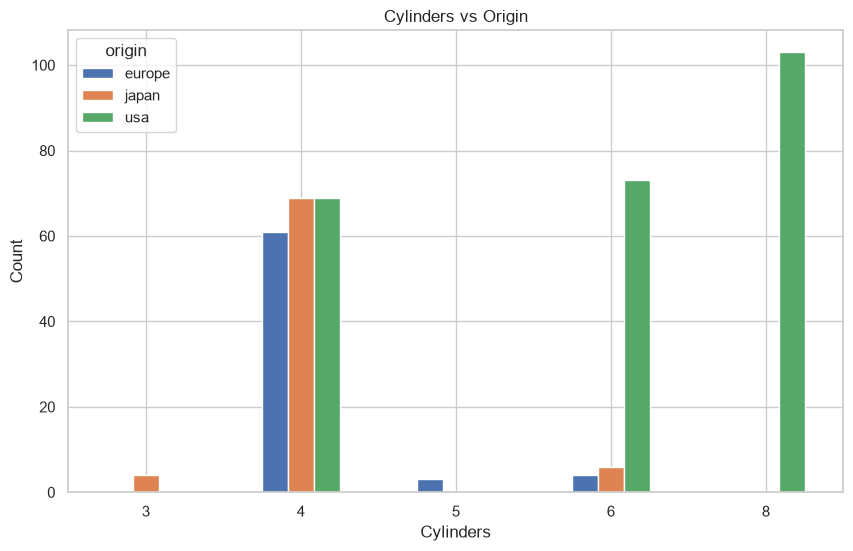

In [13]:
# TODO: Create a crosstab of cylinders vs origin and visualise as a bar chart

crosstab_cyl_origin = pd.crosstab(df['cylinders'], df['origin'])
print("Crosstab of Cylinders vs Origin:")
display(crosstab_cyl_origin)

crosstab_cyl_origin.plot(kind='bar', figsize=(10, 6))
plt.title('Cylinders vs Origin')
plt.ylabel('Count')
plt.xlabel('Cylinders')
plt.xticks(rotation=0)
plt.show()

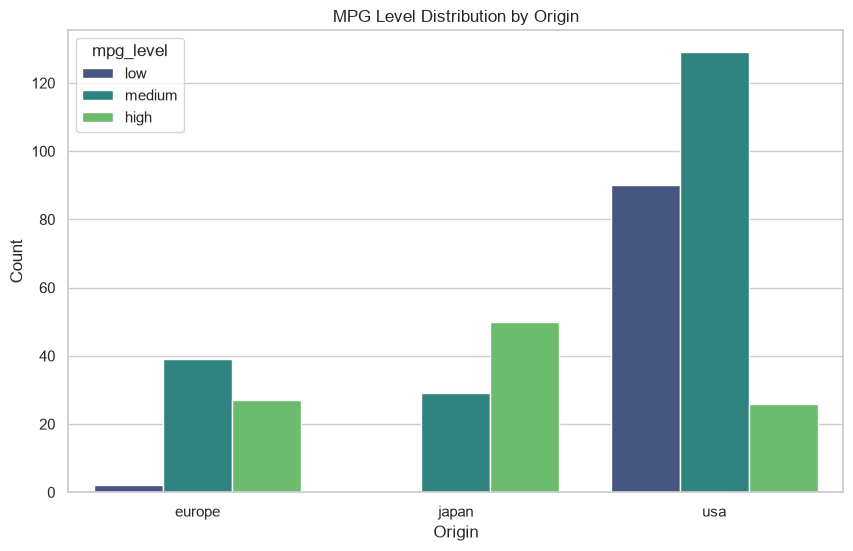

In [14]:
# TODO: Plot a countplot of mpg_level grouped by origin (use hue='mpg_level')

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='origin', hue='mpg_level', palette='viridis')
plt.title('MPG Level Distribution by Origin')
plt.xlabel('Origin')
plt.ylabel('Count')
plt.show()

**Q3.** Which origin has **no** vehicles with low mpg_level?  
**Answer:** _______________

**Q4.** Which cylinder count is most common, and what percentage does it represent?  
**Answer:** _______________


## Task 6 — Numerical EDA

In [15]:
# TODO: For each numerical column plot:
#   (a) Histogram + KDE  (b) Boxplot
# Arrange in a grid (n_cols rows × 2 columns)



In [16]:
# TODO: Write a function tukey_outliers(series) that returns the outlier values
# using the IQR (Tukey) rule: Q1 - 1.5*IQR  and  Q3 + 1.5*IQR
# Then print the outlier count for each numerical column

def tukey_outliers(series):
    # TODO: implement
    pass



In [17]:
# TODO: Plot a correlation heatmap for all numerical columns (use annot=True)



In [18]:
# TODO: Create a pairplot of numerical columns, coloured by mpg_level



**Q5.** Which two numerical features have the strongest negative correlation with mpg?  
**Answer:** _______________

**Q6.** Is the `acceleration` distribution approximately Gaussian? Justify briefly.  
**Answer:** _______________


## Task 7 — Numerical vs Categorical

In [19]:
# TODO: Plot boxenplots of all numerical features grouped by 'origin'
# (1 row × 5 column subplot grid)



In [20]:
# TODO: Plot violinplots of all numerical features grouped by 'mpg_level'



In [21]:
# TODO: Plot a line chart showing mean mpg per model_year



**Q7.** On average, which origin produces cars with the lowest mpg?  
**Answer:** _______________

**Q8.** Describe in one sentence how mpg changes as model_year increases.  
**Answer:** _______________


## Task 8 — Summary Table
Fill in the table below based on your analysis.

| Feature | Relationship with MPG | Strength |
|---|---|---|
| displacement | | |
| horsepower | | |
| weight | | |
| acceleration | | |
| cylinders | | |
| origin | | |
| model_year | | |
